In [148]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams.update({
    'figure.dpi': 100,
    'figure.figsize': (10, 6),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 2,
    'axes.labelsize': 15,
    'axes.labelcolor': 'black',
    'savefig.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'mathtext.fontset': 'cm',

    'savefig.bbox': 'tight',
    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,
})

In [149]:
data1 = np.loadtxt("./Data-20260606/01.dat")
data2 = np.loadtxt("./Data-20260606/02.dat")
data3 = np.loadtxt("./Data-20260606/03.dat")
data4 = np.loadtxt("./Data-20260606/04.dat")
data5 = np.loadtxt("./Data-20260606/05.dat")
data6 = np.loadtxt("./Data-20260606/06.dat")
data7 = np.loadtxt("./Data-20260606/07.dat")
data8 = np.loadtxt("./Data-20260606/08.dat")
data9 = np.loadtxt("./Data-20260606/09.dat")
data10 = np.loadtxt("./Data-20260606/10.dat")
data11 = np.loadtxt("./Data-20260606/11.dat")
data12 = np.loadtxt("./Data-20260606/12.dat")
data13 = np.loadtxt("./Data-20260606/13.dat")
data14 = np.loadtxt("./Data-20260606/14.dat")
data15 = np.loadtxt("./Data-20260606/15.dat")
data16 = np.loadtxt("./Data-20260606/16.dat")
data17 = np.loadtxt("./Data-20260606/17.dat")

In [150]:
datasets = [
    (data1, "300 K", 'red', 'o'),
    (data2, "290 K", 'blue', 's'),
    (data3, "280 K", 'green', '^'),
    (data4, "270 K", 'orange', 'D'),
    (data5, "260 K", 'purple', 'p'),
    (data6, "250 K", 'brown', '*'),
    (data7, "240 K", 'pink', '8'),
    (data8, "220 K", 'gray', 'H'),

    # (data9, "300 K", 'olive', 'X'),
    # (data10, "290 K", 'cyan', 'v'),
    # (data11, "280 K", 'magenta', '<'),
    # (data12, "270 K", 'lime', '>'),
    # (data13, "260 K", 'teal', 'o'),
    # (data14, "250 K", 'navy', 's'),
    # (data15, "240 K", 'maroon', '^'),
    # (data16, "230 K", 'silver', 'D'),
    # (data17, "220 K", 'gold', 'p')
]

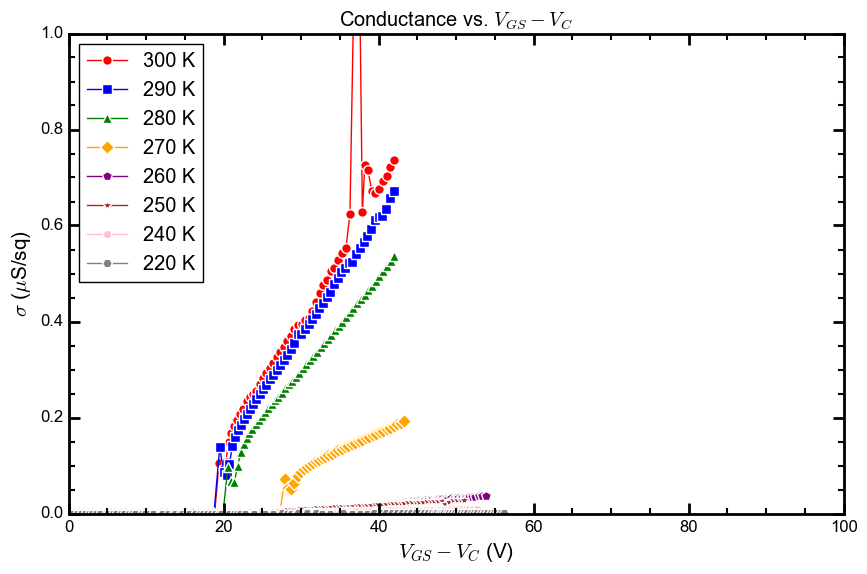

In [151]:
for data, label, color, marker in datasets:
    V_GS = data[:, 0]
    I_DS = data[:, 1]
    V_DS = data[:, 2]
    V_C = 0.5* (data[:, 4] + data[:, 5])
    V_12 = data[:, 6]
    sigma = data[:, 7]

    window_size = 1
    window = np.ones(window_size) / window_size

    V_del_smooth = np.convolve(-(V_GS - V_C), window, mode='same')
    sigma_smooth = np.convolve(sigma, window, mode='same')
    sigma_plot = sigma_smooth * 1e6
    plt.plot(V_del_smooth, sigma_plot, label=label, color=color, marker=marker, linestyle='-', markeredgecolor="white", markeredgewidth=1, markersize=7)

plt.xlabel(r"$V_{GS} - V_C$ (V)")
plt.ylabel(r"$\sigma$ ($\mu$S/sq)")  
plt.xlim(0, 100)
plt.ylim(0, 1.0)
plt.title("Conductance vs. $V_{GS} - V_C$")
plt.legend(numpoints=1, loc='upper left')
plt.show()


300 K: slope = 0.030411, intercept = -0.541878, R² = 0.9966, V_T = 17.82 V, mu = 5.41e+06 cm²/Vs
290 K: slope = 0.0363846, intercept = -0.853333, R² = 0.9930, V_T = 23.45 V, mu = 6.47e+06 cm²/Vs
280 K: slope = 0.0216934, intercept = -0.375396, R² = 0.9996, V_T = 17.30 V, mu = 3.86e+06 cm²/Vs
270 K: slope = 0.00714279, intercept = -0.11762, R² = 0.9983, V_T = 16.47 V, mu = 1.27e+06 cm²/Vs
260 K: slope = 0.00133913, intercept = -0.035011, R² = 0.9857, V_T = 26.14 V, mu = 2.38e+05 cm²/Vs
250 K: slope = 0.000699481, intercept = -0.00778921, R² = 0.7086, V_T = 11.14 V, mu = 1.24e+05 cm²/Vs
240 K: slope = 0.00025634, intercept = -0.00416442, R² = 0.9992, V_T = 16.25 V, mu = 4.56e+04 cm²/Vs
220 K: slope = 2.74647e-05, intercept = -0.000744496, R² = 0.7979, V_T = 27.11 V, mu = 4.88e+03 cm²/Vs


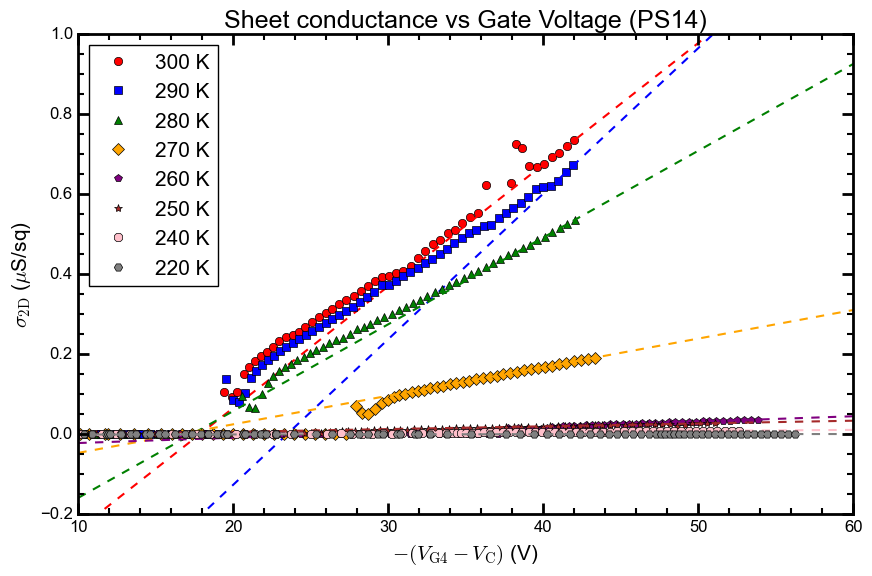

In [152]:

C = 1.8e-9
A = 32e-6
Ci = C / A


fit_ranges = {
    "300 K": (40, 63),
    "290 K": (40, 96),
    "280 K": (40, 63),
    "270 K": (40, 63),
    "260 K": (40, 63),
    "250 K": (40, 63),
    "240 K": (40, 63),
    "220 K": (40, 63),
}

for data, label, color, marker in datasets:
    V_GS = data[:, 0]
    I_DS = data[:, 1]
    V_DS = data[:, 2]
    V_C = 0.5 * (data[:, 4] + data[:, 5])
    V_12 = data[:, 6]
    sigma = data[:, 7]

    window_size = 1
    window = np.ones(window_size) / window_size

    V_del_smooth = np.convolve(-(V_GS - V_C), window, mode='same')
    sigma_smooth = np.convolve(sigma, window, mode='same')
    sigma_plot = sigma_smooth * 1e6

    plt.plot(
        V_del_smooth,
        sigma_plot,
        label=label,
        color=color,
        marker=marker,
        markevery=1,
        ls='None',
        markersize=6,
    )

    fit_vmin, fit_vmax = fit_ranges[label]
    mask = (V_del_smooth >= fit_vmin) & (V_del_smooth <= fit_vmax)
    x_fit = V_del_smooth[mask]
    y_fit = sigma_plot[mask]

    if x_fit.size >= 2:
        slope, intercept = np.polyfit(x_fit, y_fit, 1)
        print(f"{label}: slope = {slope:.6g}, intercept = {intercept:.6g}, R² = {np.corrcoef(x_fit, y_fit)[0, 1]**2:.4f}, V_T = {-intercept/slope:.2f} V, mu = {slope / Ci*1e4:.2e} cm²/Vs")
        x_line = np.linspace(10, 100, 200)
        y_line = slope * x_line + intercept
        plt.plot(
            x_line,
            y_line,
            color=color,
            lw=1.5,
            linestyle='--',
        )

plt.xlabel(r"$-(V_\text{G4} - V_\text{C})$ (V)", fontsize=15)
plt.ylabel(r"$\sigma_\text{2D}$ ($\mu$S/sq)", fontsize=15)
plt.xlim(10, 60)
plt.ylim(-0.2, 1)
plt.legend(frameon=True, loc='upper left', numpoints=1, fontsize=15)
plt.title("Sheet conductance vs Gate Voltage (PS14)", fontsize=18)
plt.savefig("vdP_sigma.eps", format='eps')
plt.show()

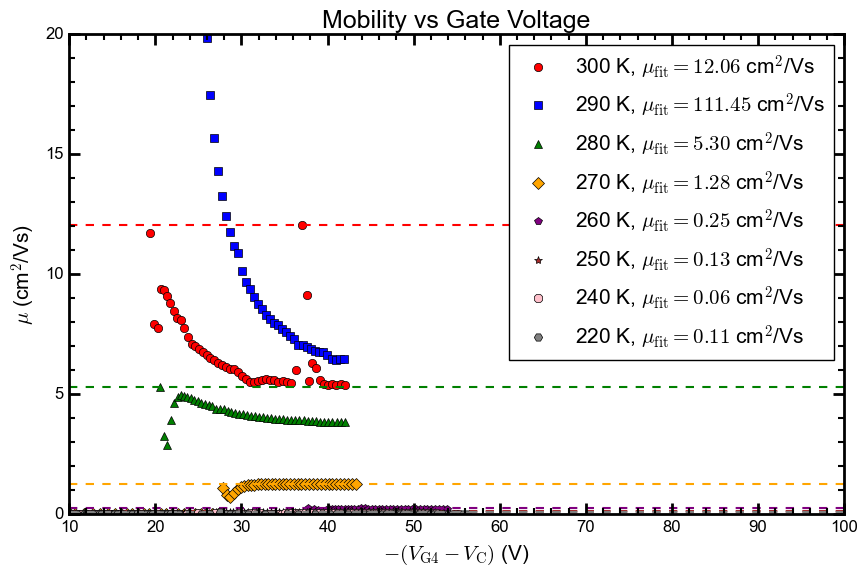

In [153]:
for data, label, color, marker in datasets:
    V_GS = data[:, 0]
    sigma = data[:, 7]
    V_C = 0.5 * (data[:, 4] + data[:, 5])

    V_del_smooth = np.convolve(-(V_GS - V_C), window, mode='same')
    sigma_smooth = np.convolve(sigma, window, mode='same')
    sigma_plot = sigma_smooth * 1e6

    fit_vmin, fit_vmax = fit_ranges[label]
    mask = (V_del_smooth >= fit_vmin) & (V_del_smooth <= fit_vmax)
    x_fit = V_del_smooth[mask]
    y_fit = sigma_plot[mask]

    if x_fit.size >= 2:
        slope, intercept = np.polyfit(x_fit, y_fit, 1)
        V_T = -intercept / slope

        denom = Ci * (V_del_smooth - V_T)
        mu = np.full_like(V_del_smooth, np.nan, dtype=float)
        valid = np.isfinite(denom) & (np.abs(denom) > 1e-12)
        mu[valid] = (sigma_plot[valid] * 1e-6) / denom[valid] * 1e4  # cm^2/Vs

        plot_valid = np.isfinite(mu)
        mu_max = mu[plot_valid].max()
        plt.plot(
            V_del_smooth[plot_valid],
            mu[plot_valid],
            color=color,
            marker=marker,
            ls='None',
            markersize=6,
            label=fr"{label}, $\mu_\text{{fit}} = {mu_max:.2f}$ cm$^2$/Vs",
        )
        plt.axhline(mu_max, color=color, ls='--', lw=1.5)

plt.xlabel(r"$-(V_\text{G4} - V_\text{C})$ (V)", fontsize=15)
plt.ylabel(r"$\mu$ (cm$^2$/Vs)", fontsize=15)
plt.xlim(10, 100)
plt.ylim(0, 20)
plt.legend(frameon=True, numpoints=1, fontsize=15)
plt.title("Mobility vs Gate Voltage", fontsize=18)
plt.savefig("vdP_mobility.eps", format='eps')
plt.show()